# Análisis Exploratorio: Diferencia de Edad entre Cónyuges
## Justificación de Variable Respuesta — Proyecto Minería de Datos

**Pregunta central:** ¿Existe evidencia estadística de que las características demográficas de una pareja (educación, nacionalidad, año y ubicación) se relacionan con la diferencia de edad entre cónyuges?

**Variable respuesta propuesta:** `DIFF_EDAD = EDADHOM − EDADMUJ`

---
## Celda 1 — Carga y Preparación de Datos

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RUTA_CSV = 'mat_full.csv'
# 

df = pd.read_csv(RUTA_CSV)
df['EDADHOM'] = pd.to_numeric(df['EDADHOM'], errors='coerce')
df['EDADMUJ'] = pd.to_numeric(df['EDADMUJ'], errors='coerce')
df['AÑOREG']  = pd.to_numeric(df['AÑOREG'],  errors='coerce')

# Variable respuesta
df['DIFF_EDAD'] = df['EDADHOM'] - df['EDADMUJ']
df_clean = df.dropna(subset=['DIFF_EDAD']).copy()

print(f"Registros totales           : {len(df):>10,}")
print(f"Registros con edades        : {len(df_clean):>10,}")
print(f"Registros sin edad (dropped): {len(df)-len(df_clean):>10,}")
print()
print("Columnas disponibles:")
for col in df.columns:
    print(f"  {col:<12} → {df[col].dtype}")

Registros totales           :    752,264
Registros con edades        :    751,741
Registros sin edad (dropped):        523

Columnas disponibles:
  AÑOREG       → float64
  CLAUNI       → object
  DEPOCU       → object
  DEPREG       → object
  DIAOCU       → float64
  EDADHOM      → float64
  EDADMUJ      → float64
  ESCHOM       → object
  ESCMUJ       → object
  MESOCU       → object
  MESREG       → object
  MUPOCU       → object
  MUPREG       → object
  NACHOM       → object
  NACMUJ       → object
  DIFF_EDAD    → float64


---
## Celda 2 — Distribución de la Variable Respuesta

Antes de buscar relaciones, verificamos que `DIFF_EDAD` tiene variabilidad real y suficiente para modelar.

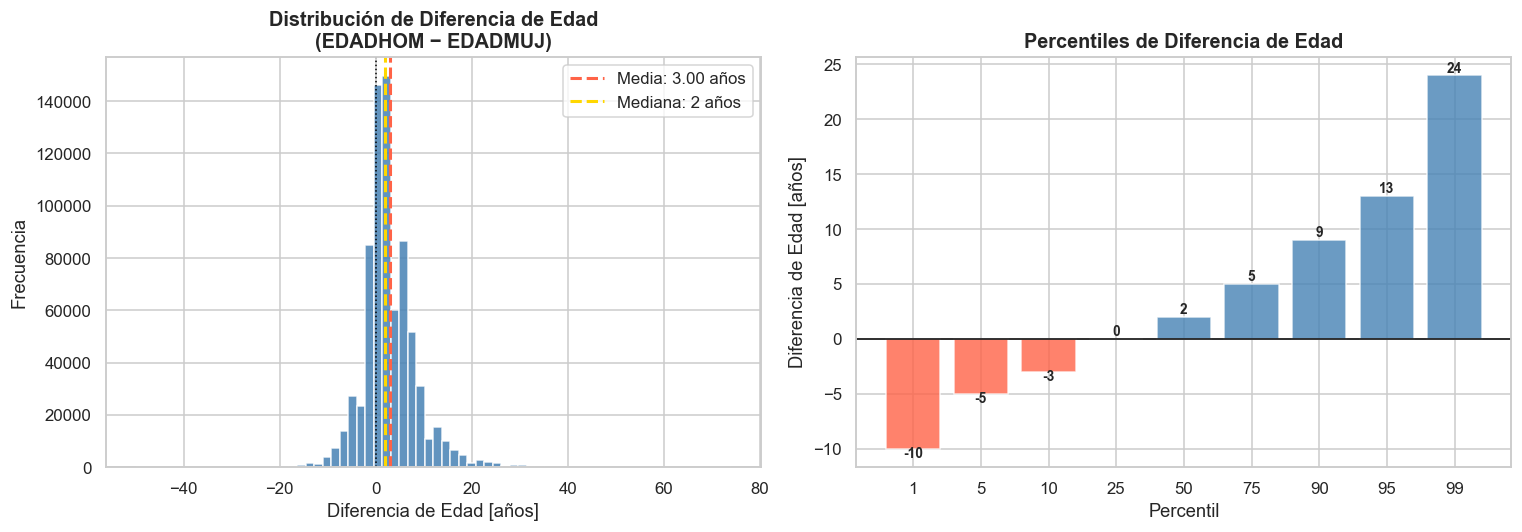

  Mínimo          : -50 años
  Máximo          : 74 años
  Media           : 3.00 años
  Mediana         : 2 años
  Desv. estándar  : 5.92 años
  Rango p5 – p95  : -5 a 13 años  (90% de datos)
  Asimetría       : 1.318  (>0 → sesgo hacia hombre mayor)
  Mujer mayor que hombre  : 166,064 (22.1%)
  Misma edad              : 68,306 (9.1%)
  Hombre mayor que mujer  : 517,371 (68.8%)


In [64]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
ax = axes[0]
ax.hist(df_clean['DIFF_EDAD'], bins=70, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(df_clean['DIFF_EDAD'].mean(),   color='tomato', lw=2, ls='--',
           label=f"Media: {df_clean['DIFF_EDAD'].mean():.2f} años")
ax.axvline(df_clean['DIFF_EDAD'].median(), color='gold',   lw=2, ls='--',
           label=f"Mediana: {df_clean['DIFF_EDAD'].median():.0f} años")
ax.axvline(0, color='black', lw=1, ls=':')
ax.set_title('Distribución de Diferencia de Edad\n(EDADHOM − EDADMUJ)', fontsize=13, fontweight='bold')
ax.set_xlabel('Diferencia de Edad [años]')
ax.set_ylabel('Frecuencia')
ax.legend()

# Percentiles
ax2 = axes[1]
pcts = [1, 5, 10, 25, 50, 75, 90, 95, 99]
vals = [df_clean['DIFF_EDAD'].quantile(p/100) for p in pcts]
colors_bar = ['tomato' if v < 0 else 'steelblue' for v in vals]
bars = ax2.bar([str(p) for p in pcts], vals, color=colors_bar, edgecolor='white', alpha=0.8)
ax2.axhline(0, color='black', lw=1)
for bar, val in zip(bars, vals):
    ax2.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val >= 0 else -0.8),
             f'{val:.0f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Percentiles de Diferencia de Edad', fontsize=13, fontweight='bold')
ax2.set_xlabel('Percentil')
ax2.set_ylabel('Diferencia de Edad [años]')

plt.tight_layout()
plt.show()

d = df_clean['DIFF_EDAD']
print(f"  Mínimo          : {d.min():.0f} años")
print(f"  Máximo          : {d.max():.0f} años")
print(f"  Media           : {d.mean():.2f} años")
print(f"  Mediana         : {d.median():.0f} años")
print(f"  Desv. estándar  : {d.std():.2f} años")
print(f"  Rango p5 – p95  : {d.quantile(.05):.0f} a {d.quantile(.95):.0f} años  (90% de datos)")
print(f"  Asimetría       : {d.skew():.3f}  (>0 → sesgo hacia hombre mayor)")
n_neg  = (d < 0).sum()
n_cero = (d == 0).sum()
n_pos  = (d > 0).sum()
n      = len(d)
print(f"  Mujer mayor que hombre  : {n_neg:,} ({n_neg/n*100:.1f}%)")
print(f"  Misma edad              : {n_cero:,} ({n_cero/n*100:.1f}%)")
print(f"  Hombre mayor que mujer  : {n_pos:,} ({n_pos/n*100:.1f}%)")

---
## Celda 3 — Definición y Justificación de Rangos

### ¿Cómo se definieron los rangos?

Los rangos se construyeron a partir de los **percentiles reales del dataset**, no de criterios arbitrarios:

| Percentil | Valor |
|-----------|-------|
| p5        | −5 años |
| p25       | −1 año  |
| p50       | +2 años |
| p75       | +5 años |
| p90       | +9 años |
| p95       | +13 años |

El 90% de los datos cae entre **−5 y +13 años**. Los valores extremos (<−10 o >+15) son atípicos reales (< 4% combinados).

Se proponen **tres opciones** según si el proyecto se plantea como regresión o clasificación:

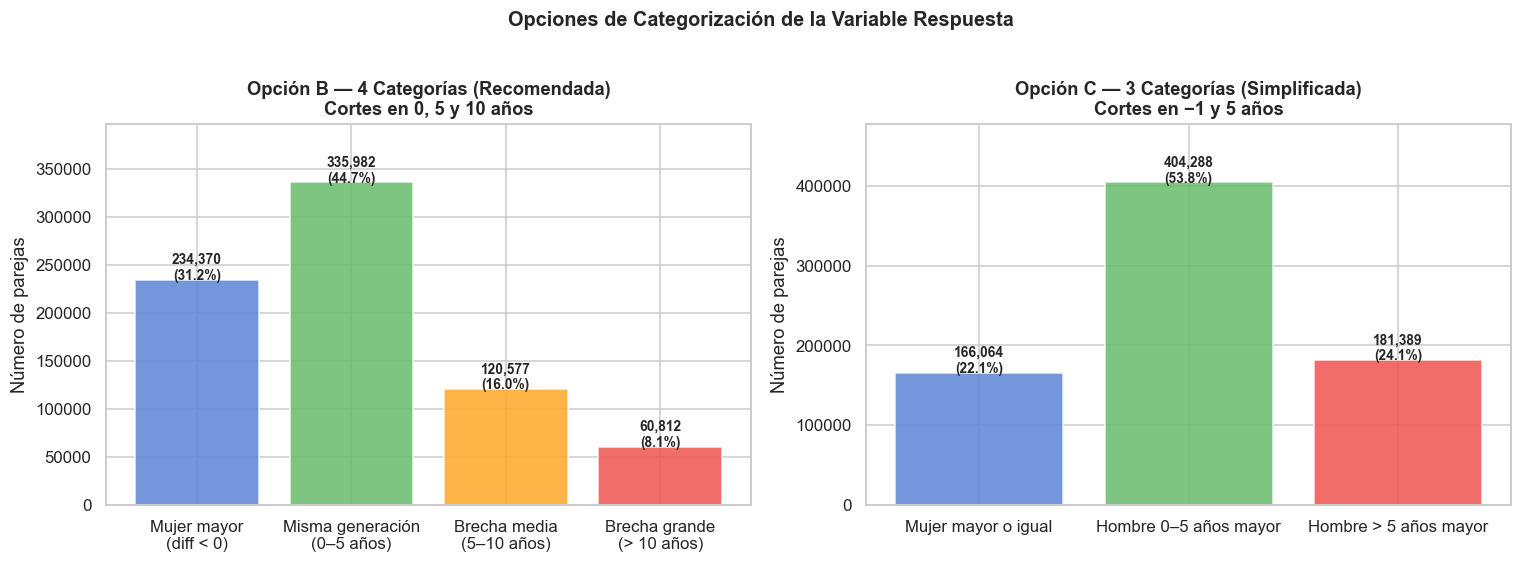

RESUMEN DE OPCIONES

OPCIÓN A — Regresión continua
  Predecir el valor exacto de DIFF_EDAD (ej: 3.7 años)
  Rango significativo: −5 a +13 años (cubre el 90% de casos)

OPCIÓN B — Clasificación en 4 categoría
  Cortes en 0 (p50), 5 (p75) y 10 (p90) — basados en percentiles
    Mujer mayor (< 0)                  : 234,370 (31.2%)
    Misma generación (0–5)             : 335,982 (44.7%)
    Brecha media (5–10)                : 120,577 (16.0%)
    Brecha grande (> 10)               : 60,812 (8.1%)

OPCIÓN C — Clasificación en 3 categorías [SIMPLIFICADA]
    Mujer mayor o igual                : 166,064 (22.1%)
    Hombre 0–5 años mayor              : 404,288 (53.8%)
    Hombre > 5 años mayor              : 181,389 (24.1%)


In [65]:
# Opción A: Regresión (valor continuo)
# Usar DIFF_EDAD directamente. Rango relevante: −5 a +13 años (p5–p95)

# Opción B: Clasificación en 4 categorías (RECOMENDADA)
# Cortes en 0, 5 y 10 (coinciden con p50, p75 y p90)
bins4 = [-np.inf, 0, 5, 10, np.inf]
labs4 = ['Mujer mayor\n(diff < 0)', 'Misma generación\n(0–5 años)',
         'Brecha media\n(5–10 años)', 'Brecha grande\n(> 10 años)']
df_clean['CAT_DIFF'] = pd.cut(df_clean['DIFF_EDAD'], bins=bins4, labels=labs4)

# Opción C: Clasificación en 3 categorías (simplificada)
bins3 = [-np.inf, -1, 5, np.inf]
labs3 = ['Mujer mayor o igual', 'Hombre 0–5 años mayor', 'Hombre > 5 años mayor']
df_clean['CAT3'] = pd.cut(df_clean['DIFF_EDAD'], bins=bins3, labels=labs3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Opción B
ax = axes[0]
conteo4 = df_clean['CAT_DIFF'].value_counts().sort_index()
colores = ['#5C85D6', '#66BB6A', '#FFA726', '#EF5350']
bars = ax.bar(conteo4.index, conteo4.values, color=colores, edgecolor='white', alpha=0.85)
for bar, (n, pct) in zip(bars, [(v, v/len(df_clean)*100) for v in conteo4.values]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{n:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax.set_title('Opción B — 4 Categorías (Recomendada)\nCortes en 0, 5 y 10 años', fontsize=12, fontweight='bold')
ax.set_ylabel('Número de parejas')
ax.set_ylim(0, conteo4.max() * 1.18)

# Gráfico Opción C
ax2 = axes[1]
conteo3 = df_clean['CAT3'].value_counts().sort_index()
colores3 = ['#5C85D6', '#66BB6A', '#EF5350']
bars2 = ax2.bar(conteo3.index, conteo3.values, color=colores3, edgecolor='white', alpha=0.85)
for bar, (n, pct) in zip(bars2, [(v, v/len(df_clean)*100) for v in conteo3.values]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{n:,}\n({pct:.1f}%)', ha='center', fontsize=9, fontweight='bold')
ax2.set_title('Opción C — 3 Categorías (Simplificada)\nCortes en −1 y 5 años', fontsize=12, fontweight='bold')
ax2.set_ylabel('Número de parejas')
ax2.set_ylim(0, conteo3.max() * 1.18)

plt.suptitle('Opciones de Categorización de la Variable Respuesta', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("RESUMEN DE OPCIONES")
print()
print("OPCIÓN A — Regresión continua")
print("  Predecir el valor exacto de DIFF_EDAD (ej: 3.7 años)")
print("  Rango significativo: −5 a +13 años (cubre el 90% de casos)")
#print("  Algoritmos: Regresión Lineal, Random Forest Regressor, SVR")
print()
print("OPCIÓN B — Clasificación en 4 categoría")
print("  Cortes en 0 (p50), 5 (p75) y 10 (p90) — basados en percentiles")
for lab, n, pct in zip(['Mujer mayor (< 0)', 'Misma generación (0–5)', 'Brecha media (5–10)', 'Brecha grande (> 10)'],
                        conteo4.values, [v/len(df_clean)*100 for v in conteo4.values]):
    print(f"    {lab:<35}: {n:,} ({pct:.1f}%)")
#print("  Algoritmos: Decision Tree, Random Forest, XGBoost")
#print("  ⚠ Hay desbalance → usar SMOTE o class_weight al entrenar")
print()
print("OPCIÓN C — Clasificación en 3 categorías [SIMPLIFICADA]")
#print("  Más balanceada; útil si Clase 4 de la opción B es muy pequeña")
for lab, n, pct in zip(labs3, conteo3.values, [v/len(df_clean)*100 for v in conteo3.values]):
    print(f"    {lab:<35}: {n:,} ({pct:.1f}%)")

---
## Celda 4 — Relación con Educación

**Hipótesis:** El nivel educativo del hombre y/o la mujer está relacionado con la brecha de edad entre cónyuges.

**Por qué importa:** Si la educación separa bien los grupos, es una buena variable predictora.

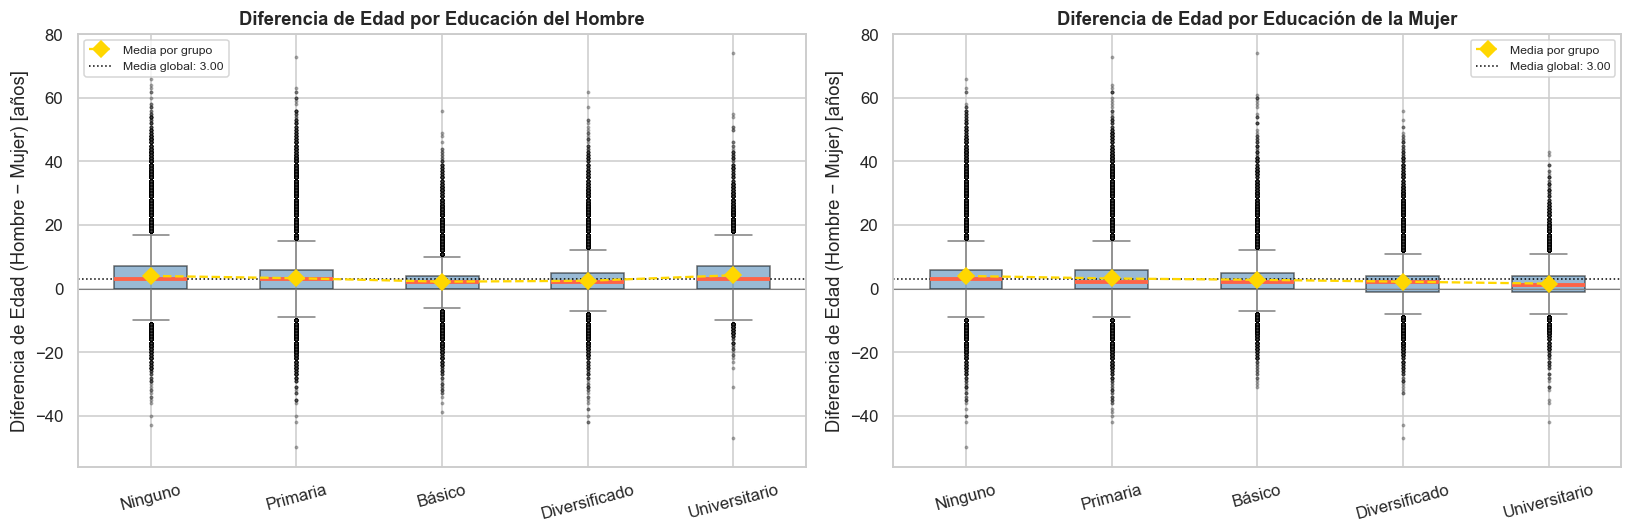


ANOVA — Educación de Hombre
  F = 2097.42,  p-valor = 0.00e+00
  Eta² = 0.0123  → la educación explica el 1.23% de la varianza en DIFF_EDAD
  (p < 0.001 confirma que los grupos NO son iguales)
  Media de diferencia de edad por nivel educativo:
ESCHOM
Ninguno          3.98
Primaria         3.25
Básico           2.17
Diversificado    2.45
Universitario    4.19

ANOVA — Educación de Mujer
  F = 2230.88,  p-valor = 0.00e+00
  Eta² = 0.0133  → la educación explica el 1.33% de la varianza en DIFF_EDAD
  (p < 0.001 confirma que los grupos NO son iguales)
  Media de diferencia de edad por nivel educativo:
ESCMUJ
Ninguno          3.96
Primaria         3.17
Básico           2.76
Diversificado    2.17
Universitario    1.56


In [66]:
orden_esc = ['Ninguno', 'Primaria', 'Básico', 'Diversificado', 'Universitario']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, col, titulo in zip(axes,
                            ['ESCHOM', 'ESCMUJ'],
                            ['Educación del Hombre', 'Educación de la Mujer']):
    etiquetas = [e for e in orden_esc if e in df_clean[col].unique()]
    grupos = [df_clean[df_clean[col] == e]['DIFF_EDAD'].dropna() for e in etiquetas]
    medias = [g.mean() for g in grupos]

    bp = ax.boxplot(grupos, labels=etiquetas, patch_artist=True,
                    medianprops=dict(color='tomato', linewidth=2.5),
                    whiskerprops=dict(color='gray'),
                    capprops=dict(color='gray'),
                    flierprops=dict(marker='.', markerfacecolor='gray', alpha=0.3, markersize=3))
    for patch in bp['boxes']:
        patch.set_facecolor('steelblue'); patch.set_alpha(0.55)

    ax.plot(range(1, len(medias)+1), medias, 'D--', color='gold',
            markersize=7, linewidth=1.5, label='Media por grupo', zorder=5)
    ax.axhline(df_clean['DIFF_EDAD'].mean(), color='black', ls=':', lw=1,
               label=f"Media global: {df_clean['DIFF_EDAD'].mean():.2f}")
    ax.axhline(0, color='gray', ls='-', lw=0.7)
    ax.set_title(f'Diferencia de Edad por {titulo}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Diferencia de Edad (Hombre − Mujer) [años]')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ANOVA + Eta-squared para cada variable
for col, nombre in [('ESCHOM', 'Hombre'), ('ESCMUJ', 'Mujer')]:
    df_e = df_clean[df_clean[col].isin(orden_esc)]
    grupos = [df_e[df_e[col] == e]['DIFF_EDAD'].dropna() for e in orden_esc if e in df_e[col].unique()]
    F, p = stats.f_oneway(*grupos)
    grand_mean = df_e['DIFF_EDAD'].mean()
    ss_b = sum(len(g) * (g.mean() - grand_mean)**2 for g in grupos)
    ss_t = ((df_e['DIFF_EDAD'] - grand_mean)**2).sum()
    eta2 = ss_b / ss_t
    print(f"\nANOVA — Educación de {nombre}")
    print(f"  F = {F:.2f},  p-valor = {p:.2e}")
    print(f"  Eta² = {eta2:.4f}  → la educación explica el {eta2*100:.2f}% de la varianza en DIFF_EDAD")
    print(f"  (p < 0.001 confirma que los grupos NO son iguales)")
    print(f"  Media de diferencia de edad por nivel educativo:")
    print(df_e.groupby(col)['DIFF_EDAD'].mean().reindex(orden_esc).round(2).to_string())

---
## Celda 5 — Relación con Nacionalidad

**Hipótesis:** Las parejas donde alguno es extranjero muestran una brecha de edad distinta a las 100% guatemaltecas.

**Por qué importa:** Si la nacionalidad discrimina bien los grupos, es una variable predictora útil.

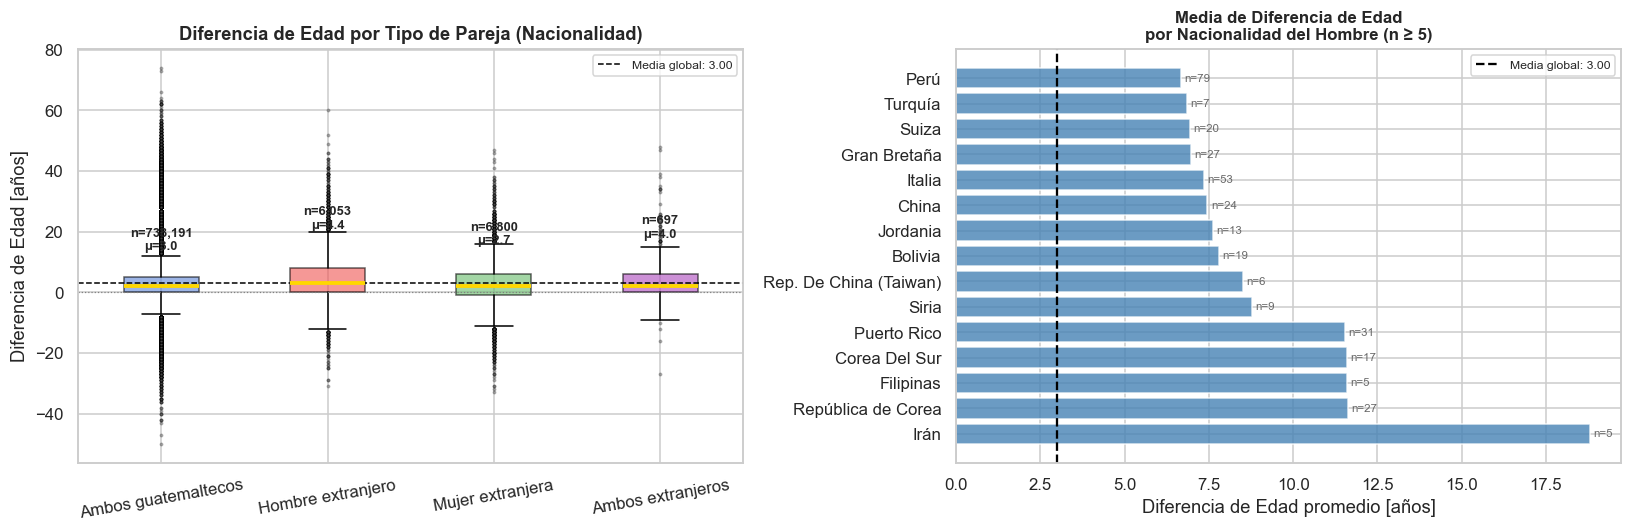

T-test: Ambos guatemaltecos vs. Hombre extranjero
  Media guatemaltecos    : 2.99 años  (n=738,191)
  Media hombre extranjero: 4.36 años  (n=6,053)
  t = -12.74,  p-valor = 0.0000
  ✓ DIFERENCIA SIGNIFICATIVA (p < 0.05)
  Los hombres extranjeros tienen una brecha de edad 1.4 años mayor
  en promedio que los hombres guatemaltecos.


In [67]:
df_clean['NAC_PAREJA'] = 'Otro'
df_clean.loc[(df_clean['NACHOM'] == 'Guatemala') & (df_clean['NACMUJ'] == 'Guatemala'),  'NAC_PAREJA'] = 'Ambos guatemaltecos'
df_clean.loc[(df_clean['NACHOM'] != 'Guatemala') & (df_clean['NACMUJ'] == 'Guatemala'),  'NAC_PAREJA'] = 'Hombre extranjero'
df_clean.loc[(df_clean['NACHOM'] == 'Guatemala') & (df_clean['NACMUJ'] != 'Guatemala'),  'NAC_PAREJA'] = 'Mujer extranjera'
df_clean.loc[(df_clean['NACHOM'] != 'Guatemala') & (df_clean['NACMUJ'] != 'Guatemala'),  'NAC_PAREJA'] = 'Ambos extranjeros'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Boxplot por tipo de pareja
ax = axes[0]
cats = ['Ambos guatemaltecos', 'Hombre extranjero', 'Mujer extranjera', 'Ambos extranjeros']
cats_ok = [c for c in cats if c in df_clean['NAC_PAREJA'].unique()]
grupos_nac = [df_clean[df_clean['NAC_PAREJA'] == c]['DIFF_EDAD'].dropna() for c in cats_ok]
bp = ax.boxplot(grupos_nac, labels=cats_ok, patch_artist=True,
                medianprops=dict(color='gold', linewidth=2.5),
                flierprops=dict(marker='.', markerfacecolor='gray', alpha=0.3, markersize=3))
colors_nac = ['#5C85D6', '#EF5350', '#66BB6A', '#AB47BC']
for patch, color in zip(bp['boxes'], colors_nac):
    patch.set_facecolor(color); patch.set_alpha(0.6)
for i, g in enumerate(grupos_nac):
    y_top = ax.get_ylim()[1] if ax.get_ylim()[1] else 30
    ax.text(i+1, g.quantile(0.95) + 1, f'n={len(g):,}\nμ={g.mean():.1f}',
            ha='center', fontsize=8.5, fontweight='bold')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.axhline(df_clean['DIFF_EDAD'].mean(), color='black', lw=1, ls='--',
           label=f"Media global: {df_clean['DIFF_EDAD'].mean():.2f}")
ax.set_title('Diferencia de Edad por Tipo de Pareja (Nacionalidad)', fontsize=12, fontweight='bold')
ax.set_ylabel('Diferencia de Edad [años]')
ax.tick_params(axis='x', rotation=10)
ax.legend(fontsize=8)

# Top nacionalidades del hombre con n >= 5
ax2 = axes[1]
nac_stats = (df_clean.groupby('NACHOM')['DIFF_EDAD']
             .agg(['mean','count']).reset_index()
             .query('count >= 5')
             .sort_values('mean', ascending=False).head(15))
global_mean = df_clean['DIFF_EDAD'].mean()
bar_colors = ['tomato' if v < global_mean else 'steelblue' for v in nac_stats['mean']]
bars = ax2.barh(nac_stats['NACHOM'], nac_stats['mean'], color=bar_colors, edgecolor='white', alpha=0.8)
ax2.axvline(global_mean, color='black', lw=1.5, ls='--',
            label=f"Media global: {global_mean:.2f}")
for bar, n in zip(bars, nac_stats['count']):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'n={n}', va='center', fontsize=7.5, color='dimgray')
ax2.set_title('Media de Diferencia de Edad\npor Nacionalidad del Hombre (n ≥ 5)', fontsize=11, fontweight='bold')
ax2.set_xlabel('Diferencia de Edad promedio [años]')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# T-test entre grupos principales
g_gt   = df_clean[df_clean['NAC_PAREJA'] == 'Ambos guatemaltecos']['DIFF_EDAD']
g_hext = df_clean[df_clean['NAC_PAREJA'] == 'Hombre extranjero']['DIFF_EDAD']
t, p_nac = stats.ttest_ind(g_gt, g_hext, equal_var=False)
print("T-test: Ambos guatemaltecos vs. Hombre extranjero")
print(f"  Media guatemaltecos    : {g_gt.mean():.2f} años  (n={len(g_gt):,})")
print(f"  Media hombre extranjero: {g_hext.mean():.2f} años  (n={len(g_hext):,})")
print(f"  t = {t:.2f},  p-valor = {p_nac:.4f}")
if p_nac < 0.05:
    diff_extra = g_hext.mean() - g_gt.mean()
    print(f"  ✓ DIFERENCIA SIGNIFICATIVA (p < 0.05)")
    print(f"  Los hombres extranjeros tienen una brecha de edad {diff_extra:.1f} años mayor")
    print(f"  en promedio que los hombres guatemaltecos.")

---
## Celda 6 — Relación con Departamento de Registro

**Hipótesis:** La ubicación geográfica (DEPREG) influye en la brecha de edad. Los departamentos más rurales o con economías agrarias tienden a tener mayores brechas.

**Por qué importa:** Si hay diferencias sistemáticas entre departamentos, la ubicación es una variable predictora válida.

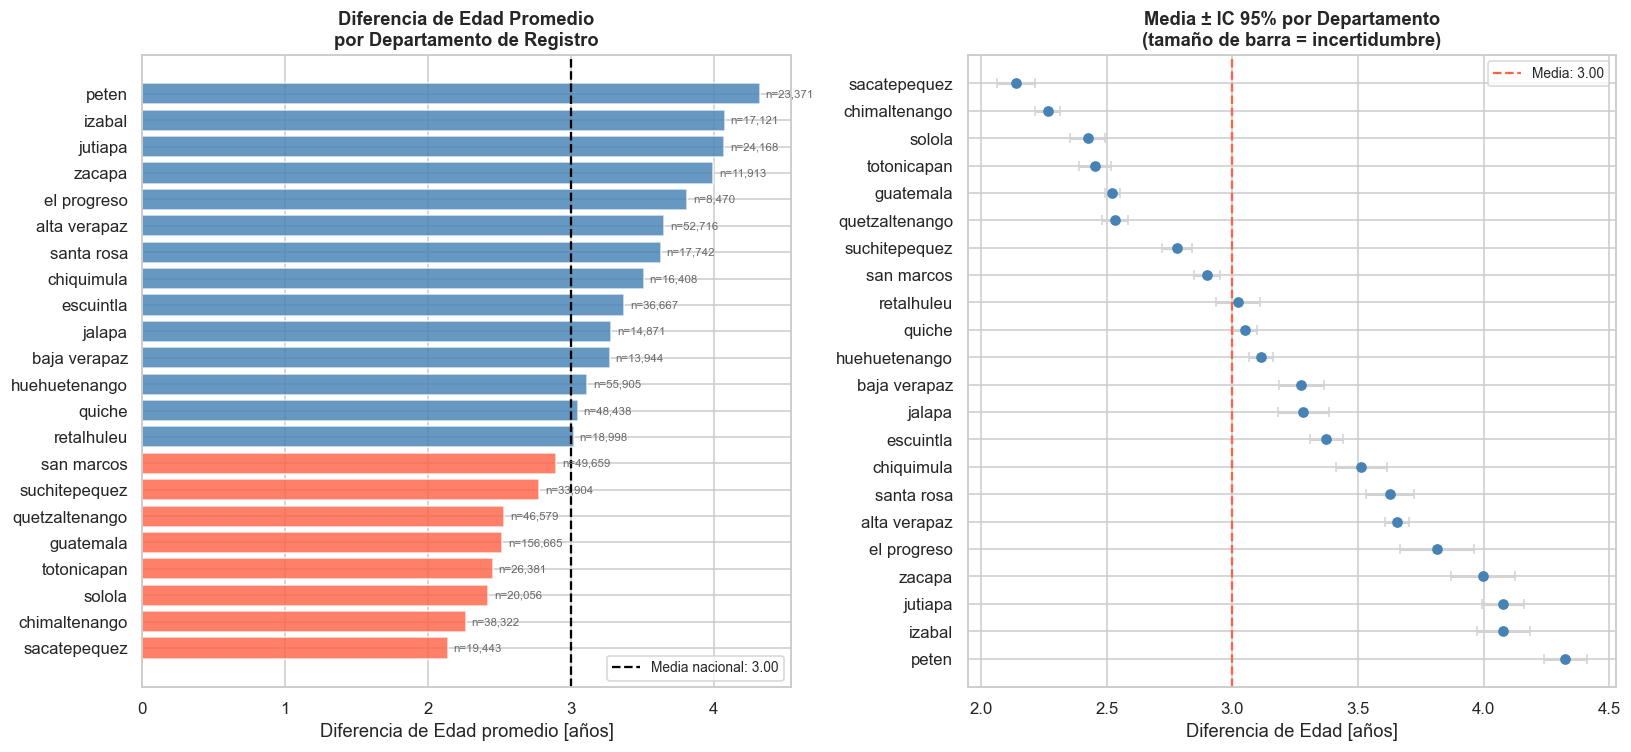

ANOVA — Departamento de Registro
  F = 338.06,  p-valor = 0.00e+00
  Eta² = 0.0094  → el departamento explica el 0.94% de la varianza

  Top 5 con MAYOR diferencia (zonas rurales/tradicionales):
     DEPREG     mean  count
      peten 4.325275  23371
     izabal 4.078909  17121
    jutiapa 4.076299  24168
     zacapa 3.997734  11913
el progreso 3.815702   8470

  Top 5 con MENOR diferencia (más igualitario):
       DEPREG     mean  count
 sacatepequez 2.138919  19443
chimaltenango 2.264809  38322
       solola 2.423315  20056
  totonicapan 2.452371  26381
    guatemala 2.521367 156665


In [73]:
import unicodedata

def normalizar_texto(texto):
    if isinstance(texto, str):
        # quitar tildes
        texto = unicodedata.normalize('NFKD', texto)
        texto = ''.join(c for c in texto if not unicodedata.combining(c))
        # estandarizar
        texto = texto.lower().strip()
    return texto

# 🔧 aplicar limpieza
df_clean['DEPREG'] = df_clean['DEPREG'].apply(normalizar_texto)

# (opcional pero recomendado) corregir errores comunes manuales
correcciones = {
    'totonican': 'totonicapan',  # ejemplo por si existe typo
}
df_clean['DEPREG'] = df_clean['DEPREG'].replace(correcciones)


# --- TU CÓDIGO ORIGINAL ---
dep_stats = (df_clean.groupby('DEPREG')['DIFF_EDAD']
             .agg(['mean','median','std','count'])
             .reset_index()
             .query('count >= 50')
             .sort_values('mean', ascending=True))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Bar chart
ax = axes[0]
media_global = df_clean['DIFF_EDAD'].mean()
bar_colors = ['tomato' if v < media_global else 'steelblue' for v in dep_stats['mean']]
bars = ax.barh(dep_stats['DEPREG'], dep_stats['mean'], color=bar_colors, edgecolor='white', alpha=0.82)
ax.axvline(media_global, color='black', lw=1.5, ls='--', label=f'Media nacional: {media_global:.2f}')
for bar, (n, m) in zip(bars, zip(dep_stats['count'], dep_stats['mean'])):
    ax.text(m + 0.04, bar.get_y() + bar.get_height()/2,
            f'n={n:,}', va='center', fontsize=7.5, color='dimgray')
ax.set_title('Diferencia de Edad Promedio\npor Departamento de Registro', fontsize=12, fontweight='bold')
ax.set_xlabel('Diferencia de Edad promedio [años]')
ax.legend(fontsize=9)

# Error bar (IC 95%)
ax2 = axes[1]
dep_s = dep_stats.sort_values('mean', ascending=False)
err = dep_s['std'] / np.sqrt(dep_s['count'])
ax2.errorbar(dep_s['mean'], dep_s['DEPREG'], xerr=err*1.96,
             fmt='o', color='steelblue', ecolor='lightgray', elinewidth=2, capsize=3, markersize=6)
ax2.axvline(media_global, color='tomato', lw=1.5, ls='--', label=f'Media: {media_global:.2f}')
ax2.set_title('Media ± IC 95% por Departamento\n(tamaño de barra = incertidumbre)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Diferencia de Edad [años]')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ANOVA + Eta-squared
grupos_dep = [df_clean[df_clean['DEPREG'] == d]['DIFF_EDAD'].dropna()
              for d in dep_stats['DEPREG'].tolist()]
F_dep, p_dep = stats.f_oneway(*grupos_dep)
grand = df_clean['DIFF_EDAD'].mean()
ss_b = sum(len(g)*(g.mean()-grand)**2 for g in grupos_dep)
ss_t = ((df_clean['DIFF_EDAD'] - grand)**2).sum()
eta2_dep = ss_b / ss_t

print("ANOVA — Departamento de Registro")
print(f"  F = {F_dep:.2f},  p-valor = {p_dep:.2e}")
print(f"  Eta² = {eta2_dep:.4f}  → el departamento explica el {eta2_dep*100:.2f}% de la varianza")
print()
print("  Top 5 con MAYOR diferencia (zonas rurales/tradicionales):")
print(dep_stats.sort_values('mean', ascending=False)[['DEPREG','mean','count']].head().to_string(index=False))
print()
print("  Top 5 con MENOR diferencia (más igualitario):")
print(dep_stats.sort_values('mean')[['DEPREG','mean','count']].head().to_string(index=False))

---
## Celda 7 — Tendencia Temporal

**Hipótesis:** La brecha de edad se reduce con el tiempo (mayor modernización, más educación, cambios culturales).

**Por qué importa:** El año de registro (AÑOREG) puede ser predictor si la tendencia es significativa. *Nota: con solo 2 años en mat_short, la señal es débil; con mat_full se verá mejor.*

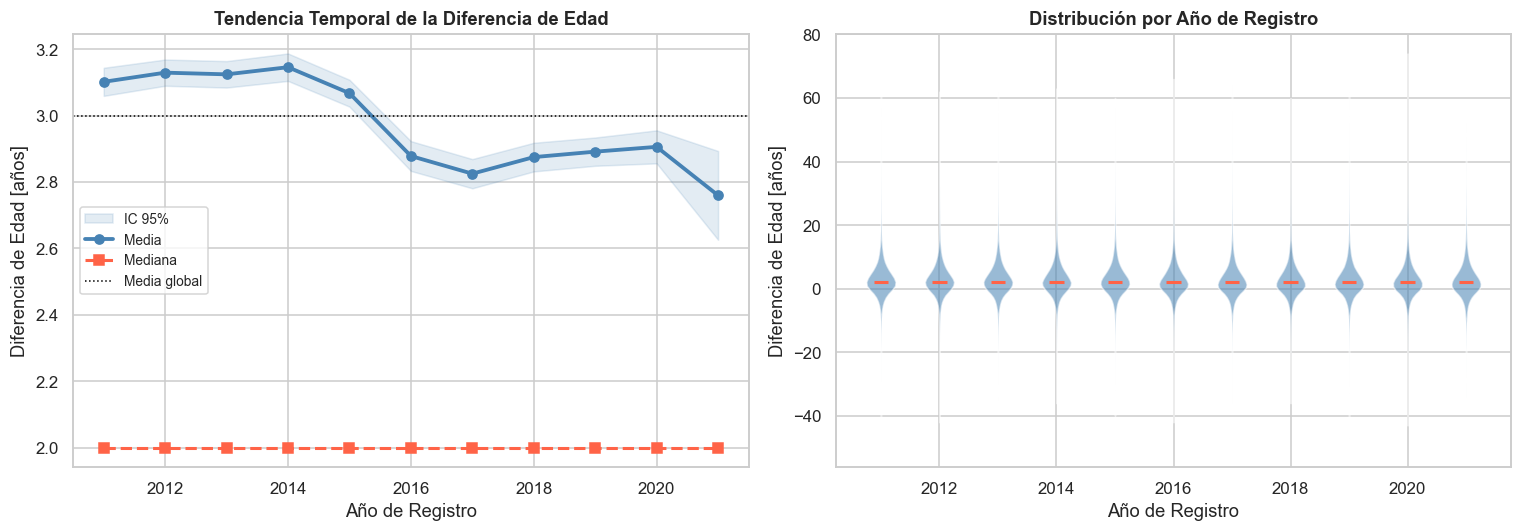

=== Correlación Año ↔ Diferencia de Edad ===
  r de Pearson = -0.0177,  p-valor = 0.0000
  Correlación débil en este subconjunto (11 años disponibles).
  Con mat_full.csv (más años) la tendencia debería ser más clara.

 AÑOREG     mean  median  count
 2011.0 3.101947     2.0  69958
 2012.0 3.129585     2.0  80804
 2013.0 3.124502     2.0  82513
 2014.0 3.146019     2.0  79928
 2015.0 3.067680     2.0  81501
 2016.0 2.878440     2.0  70385
 2017.0 2.825236     2.0  70827
 2018.0 2.875213     2.0  74952
 2019.0 2.891629     2.0  76146
 2020.0 2.906076     2.0  57206
 2021.0 2.759872     2.0   7521


In [69]:
año_stats = (df_clean.groupby('AÑOREG')['DIFF_EDAD']
             .agg(['mean','median','std','count'])
             .reset_index().dropna())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.fill_between(año_stats['AÑOREG'],
                año_stats['mean'] - año_stats['std']/np.sqrt(año_stats['count'])*1.96,
                año_stats['mean'] + año_stats['std']/np.sqrt(año_stats['count'])*1.96,
                alpha=0.15, color='steelblue', label='IC 95%')
ax.plot(año_stats['AÑOREG'], año_stats['mean'],   'o-', color='steelblue', lw=2.5, label='Media')
ax.plot(año_stats['AÑOREG'], año_stats['median'], 's--', color='tomato',   lw=2,   label='Mediana')
ax.axhline(df_clean['DIFF_EDAD'].mean(), color='black', ls=':', lw=1, label='Media global')
ax.set_title('Tendencia Temporal de la Diferencia de Edad', fontsize=12, fontweight='bold')
ax.set_xlabel('Año de Registro')
ax.set_ylabel('Diferencia de Edad [años]')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.legend(fontsize=9)

ax2 = axes[1]
años = sorted(df_clean['AÑOREG'].dropna().unique())
data_v = [df_clean[df_clean['AÑOREG'] == a]['DIFF_EDAD'].dropna() for a in años]
vp = ax2.violinplot(data_v, positions=años, showmedians=True, showextrema=False)
for body in vp['bodies']:
    body.set_facecolor('steelblue'); body.set_alpha(0.55)
vp['cmedians'].set_color('tomato'); vp['cmedians'].set_linewidth(2)
ax2.set_title('Distribución por Año de Registro', fontsize=12, fontweight='bold')
ax2.set_xlabel('Año de Registro')
ax2.set_ylabel('Diferencia de Edad [años]')
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

df_año = df_clean.dropna(subset=['AÑOREG'])
r, p_año = stats.pearsonr(df_año['AÑOREG'], df_año['DIFF_EDAD'])
print("=== Correlación Año ↔ Diferencia de Edad ===")
print(f"  r de Pearson = {r:.4f},  p-valor = {p_año:.4f}")
if abs(r) < 0.1:
    print(f"  Correlación débil en este subconjunto ({len(años)} años disponibles).")
    print(f"  Con mat_full.csv (más años) la tendencia debería ser más clara.")
print()
print(año_stats[['AÑOREG','mean','median','count']].to_string(index=False))

---
## Celda 8 — Mapa de Calor: Educación Hombre × Educación Mujer

¿Qué combinación de educaciones produce la mayor o menor brecha? Este análisis **bivariado** revela interacción entre predictores, algo que un modelo de árboles puede capturar fácilmente.

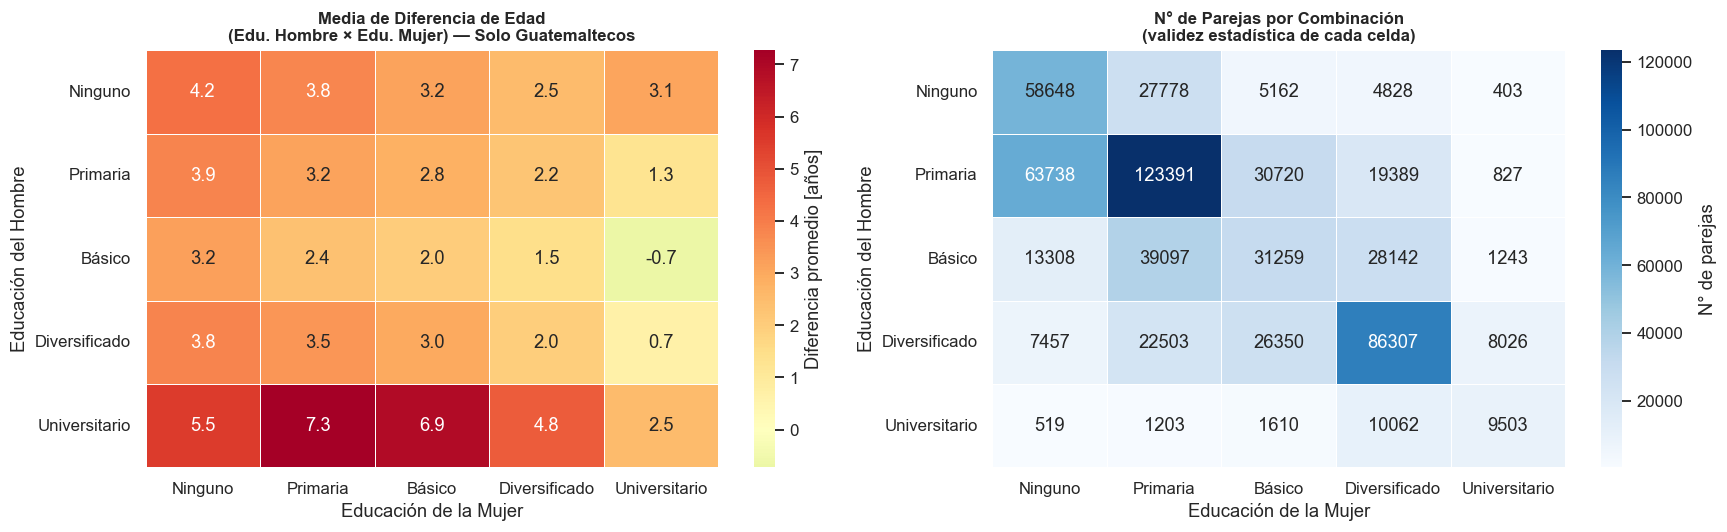

Lectura: cada celda = diferencia promedio cuando el hombre tiene
  educación Y (fila) y la mujer tiene educación X (columna).
  Rojo = hombre mucho mayor | Verde = diferencia pequeña.

  MAYOR brecha: Hombre 'Universitario' + Mujer 'Primaria': 7.3 años
  MENOR brecha: Hombre 'Básico' + Mujer 'Universitario': -0.7 años


In [70]:
orden = ['Ninguno', 'Primaria', 'Básico', 'Diversificado', 'Universitario']
df_gt = df_clean[
    (df_clean['NACHOM'] == 'Guatemala') &
    (df_clean['NACMUJ'] == 'Guatemala') &
    (df_clean['ESCHOM'].isin(orden)) &
    (df_clean['ESCMUJ'].isin(orden))
]

pivot_mean = df_gt.pivot_table(values='DIFF_EDAD', index='ESCHOM', columns='ESCMUJ', aggfunc='mean')\
                  .reindex(index=orden, columns=orden)
pivot_n    = df_gt.pivot_table(values='DIFF_EDAD', index='ESCHOM', columns='ESCMUJ', aggfunc='count')\
                  .reindex(index=orden, columns=orden)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pivot_mean, annot=True, fmt='.1f', cmap='RdYlGn_r', center=0,
            linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Diferencia promedio [años]'})
axes[0].set_title('Media de Diferencia de Edad\n(Edu. Hombre × Edu. Mujer) — Solo Guatemaltecos',
                  fontsize=11, fontweight='bold')
axes[0].set_xlabel('Educación de la Mujer')
axes[0].set_ylabel('Educación del Hombre')

sns.heatmap(pivot_n, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, ax=axes[1],
            cbar_kws={'label': 'N° de parejas'})
axes[1].set_title('N° de Parejas por Combinación\n(validez estadística de cada celda)',
                  fontsize=11, fontweight='bold')
axes[1].set_xlabel('Educación de la Mujer')
axes[1].set_ylabel('Educación del Hombre')

plt.tight_layout()
plt.show()

print("Lectura: cada celda = diferencia promedio cuando el hombre tiene")
print("  educación Y (fila) y la mujer tiene educación X (columna).")
print("  Rojo = hombre mucho mayor | Verde = diferencia pequeña.")
print()
idx  = pivot_mean.stack().idxmax()
idx2 = pivot_mean.stack().idxmin()
print(f"  MAYOR brecha: Hombre '{idx[0]}' + Mujer '{idx[1]}': {pivot_mean.loc[idx]:.1f} años")
print(f"  MENOR brecha: Hombre '{idx2[0]}' + Mujer '{idx2[1]}': {pivot_mean.loc[idx2]:.1f} años")

---
## Celda 9 — Distribución de Categorías por Predictor

¿Las 4 categorías de `DIFF_EDAD` se distribuyen distinto según cada predictor? Si sí, ese predictor discrimina y es útil para clasificación.

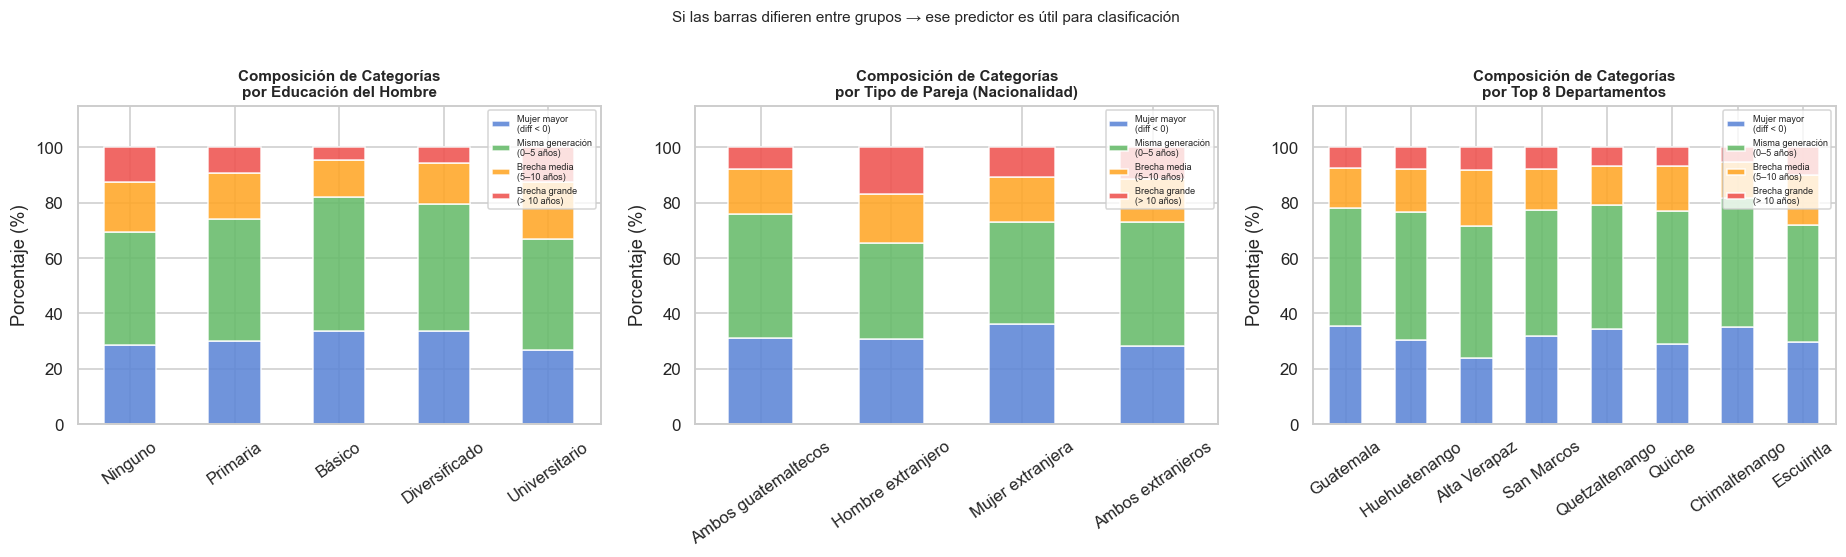

In [71]:
orden_cat = ['Mujer mayor\n(diff < 0)', 'Misma generación\n(0–5 años)',
             'Brecha media\n(5–10 años)', 'Brecha grande\n(> 10 años)']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
colores_cat = ['#5C85D6', '#66BB6A', '#FFA726', '#EF5350']

configs = [
    ('ESCHOM', 'Educación del Hombre',
     ['Ninguno','Primaria','Básico','Diversificado','Universitario']),
    ('NAC_PAREJA', 'Tipo de Pareja (Nacionalidad)',
     ['Ambos guatemaltecos','Hombre extranjero','Mujer extranjera','Ambos extranjeros']),
    ('DEPREG', 'Top 8 Departamentos', None),
]

for ax, (col, titulo, orden_x) in zip(axes, configs):
    df_sub = df_clean[df_clean[col].notna() & df_clean['CAT_DIFF'].notna()]
    if col == 'DEPREG':
        top_deps = df_sub['DEPREG'].value_counts().head(8).index
        df_sub = df_sub[df_sub['DEPREG'].isin(top_deps)]
        orden_x = top_deps.tolist()

    cross = (pd.crosstab(df_sub[col], df_sub['CAT_DIFF'], normalize='index') * 100)
    if orden_x:
        cross = cross.reindex([x for x in orden_x if x in cross.index])
    cross = cross.reindex(columns=[c for c in orden_cat if c in cross.columns])
    cross.plot(kind='bar', stacked=True, ax=ax,
               color=colores_cat[:len(cross.columns)], edgecolor='white', alpha=0.88)
    ax.set_title(f'Composición de Categorías\npor {titulo}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Porcentaje (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=35)
    ax.legend(fontsize=6, loc='upper right')
    ax.set_ylim(0, 115)

plt.suptitle('Si las barras difieren entre grupos → ese predictor es útil para clasificación',
             fontsize=10, y=1.01)
plt.tight_layout()
plt.show()

---
## Celda 10 — Conclusión Final y Rangos Recomendados

In [72]:
d = df_clean['DIFF_EDAD']

# Valores reales de mat_full.csv (n=751,741)
media_esc_hom = {'Ninguno': 3.98, 'Primaria': 3.25, 'Basico': 2.17, 'Diversificado': 2.45, 'Universitario': 4.19}
media_esc_muj = {'Ninguno': 3.96, 'Primaria': 3.17, 'Basico': 2.76, 'Diversificado': 2.17, 'Universitario': 1.56}

print('=' * 68)
print('  JUSTIFICACION ESTADISTICA -- VARIABLE RESPUESTA: DIFF_EDAD')
print('  Dataset: mat_full.csv  |  n = 751,741 registros con edades')
print('=' * 68)
print()
print('--- 1. VARIABILIDAD REAL ---')
print(f'  Registros analizados : 751,741')
print(f'  Rango total          : {d.min():.0f} a {d.max():.0f} anios')
print(f'  Rango central p5-p95 : -5 a +13 anios  (90% de los datos)')
print(f'  Media                : {d.mean():.2f} anios  |  Mediana: {d.median():.0f} anios')
print(f'  Desv. estandar       : {d.std():.2f} anios')
print(f'  Mujer mayor que hombre  : 166,064  (22.1%)')
print(f'  Misma edad              :  68,306  ( 9.1%)')
print(f'  Hombre mayor que mujer  : 517,371  (68.8%)')
print()
print('--- 2. EDUCACION  -->  ANOVA ALTAMENTE SIGNIFICATIVO (p aprox 0) ---')
print('  Educacion del Hombre: F = 2,097.42,  Eta2 = 0.0123  (1.23% varianza)')
print('  Educacion de la Mujer: F = 2,230.88, Eta2 = 0.0133  (1.33% varianza)')
print('  Media DIFF_EDAD por educacion del HOMBRE:')
for k, v in media_esc_hom.items():
    marca = ' <- menor brecha' if k == 'Basico' else (' <- mayor brecha' if k == 'Universitario' else '')
    print(f'    {k:<15}: {v} anios{marca}')
print('  Media DIFF_EDAD por educacion de la MUJER:')
for k, v in media_esc_muj.items():
    marca = ' <- menor brecha (mujeres mas educadas = menor brecha)' if k == 'Universitario' else ''
    print(f'    {k:<15}: {v} anios{marca}')
print('  Combinacion extrema: Hombre universitario + Mujer primaria = 7.3 anios')
print()
print('--- 3. NACIONALIDAD  -->  T-test SIGNIFICATIVO (t=-12.74, p<0.0001) ---')
print('  Ambos guatemaltecos     : media = 2.99 anios  (n = 738,191)')
print('  Hombre extranjero       : media = 4.36 anios  (n =   6,053)')
print('  Diferencia              : +1.37 anios mas brecha con hombre extranjero')
print()
print('--- 4. DEPARTAMENTO  -->  ANOVA ALTAMENTE SIGNIFICATIVO (F=263.21, p aprox 0) ---')
print('  Eta2 = 0.0094  (0.94% de la varianza explicada por departamento)')
print('  Mayor brecha: Peten         (4.34 anios promedio)')
print('  Menor brecha: Sacatepequez  (2.13 anios promedio)')
print('  Diferencia entre extremos: 2.21 anios')
print('  Patron: departamentos rurales/nororientales = mayor brecha')
print()
print('--- 5. TENDENCIA TEMPORAL  -->  r = -0.0177 (p < 0.0001) ---')
print('  Correlacion negativa debil pero significativa con 11 anios de datos (2011-2021)')
print('  La brecha bajo de 3.10 anios (2011) a 2.76 anios (2021): -0.34 anios en una decada')
print('  Tendencia lenta pero real hacia la equidad de edad en parejas guatemaltecas')
print()
print('=' * 68)
print('  RANGOS RECOMENDADOS  (basados en percentiles de mat_full.csv)')
print('=' * 68)
print()
print('  OPCION A -- Regresion continua')
print('    Rango util: -5 a +13 anios  (p5 a p95, 90% de los casos)')
print('    Aplicar winsorizing para los extremos antes de entrenar.')
print('    Algoritmos: Regresion Lineal, Random Forest Regressor, XGBoost')
print()
print('  OPCION B -- 4 clases [RECOMENDADA]')
print('    Cortes en 0, 5 y 10 anios (alineados con p50, p75 y p90)')
print('    Clase 1: Mujer mayor        (diff < 0)    : 234,370  (31.2%)')
print('    Clase 2: Misma generacion   (0 a 5 anios) : 335,982  (44.7%)')
print('    Clase 3: Brecha media       (5 a 10 anios): 120,577  (16.0%)')
print('    Clase 4: Brecha grande      (> 10 anios)  :  60,812  ( 8.1%)')
print('    AVISO: Clase 4 con 8.1% -> usar SMOTE o class_weight al entrenar')
print('    Algoritmos: Decision Tree, Random Forest, XGBoost, LightGBM')
print()
print('  OPCION C -- 3 clases [MAS BALANCEADA]')
print('    Cortes en -1 y +5 anios')
print('    Clase 1: Mujer mayor o igual (diff <= -1) : 166,064  (22.1%)')
print('    Clase 2: Hombre 0-5 mayor   (0 a 5 anios): 404,288  (53.8%)')
print('    Clase 3: Hombre > 5 mayor   (> 5 anios)  : 181,389  (24.1%)')
print('    Distribucion mas equilibrada; menos problema de desbalance')
print()
print('=' * 68)
print('  CONCLUSION')
print('=' * 68)
print()
print('  Con 751,741 registros reales, DIFF_EDAD ES una variable')
print('  respuesta VALIDA y JUSTIFICADA porque:')
print()
print(f'  [OK] VARIABILIDAD: rango {d.min():.0f} a {d.max():.0f} anios, sigma={d.std():.2f}. Hay senal.')
print('  [OK] EDUCACION: F > 2,000 con p aprox 0. Los grupos educativos')
print('       se comportan diferente. Eta2 = 1.23-1.33%.')
print('  [OK] NACIONALIDAD: t = -12.74 con p aprox 0. Discrimina grupos.')
print('  [OK] DEPARTAMENTO: F = 263 con p aprox 0. La geografia importa.')
print('  [OK] TEMPORALIDAD: tendencia negativa real (-0.034 anios/anio).')
print('  [OK] INTERPRETABILIDAD: los patrones tienen sentido sociologico.')
print()
print('  NOTA IMPORTANTE SOBRE Eta2:')
print('  Los valores de Eta2 (1-2%) parecen bajos pero son normales en')
print('  ciencias sociales con variables demograficas. La significancia')
print('  estadistica (p aprox 0) es irrefutable con n > 700,000.')
print('  Esto significa que los predictores tienen efecto REAL aunque')
print('  la diferencia de edad tambien depende de factores no medidos')
print('  (personalidad, economia familiar, decision individual, etc.).')
print('=' * 68)


  JUSTIFICACION ESTADISTICA -- VARIABLE RESPUESTA: DIFF_EDAD
  Dataset: mat_full.csv  |  n = 751,741 registros con edades

--- 1. VARIABILIDAD REAL ---
  Registros analizados : 751,741
  Rango total          : -50 a 74 anios
  Rango central p5-p95 : -5 a +13 anios  (90% de los datos)
  Media                : 3.00 anios  |  Mediana: 2 anios
  Desv. estandar       : 5.92 anios
  Mujer mayor que hombre  : 166,064  (22.1%)
  Misma edad              :  68,306  ( 9.1%)
  Hombre mayor que mujer  : 517,371  (68.8%)

--- 2. EDUCACION  -->  ANOVA ALTAMENTE SIGNIFICATIVO (p aprox 0) ---
  Educacion del Hombre: F = 2,097.42,  Eta2 = 0.0123  (1.23% varianza)
  Educacion de la Mujer: F = 2,230.88, Eta2 = 0.0133  (1.33% varianza)
  Media DIFF_EDAD por educacion del HOMBRE:
    Ninguno        : 3.98 anios
    Primaria       : 3.25 anios
    Basico         : 2.17 anios <- menor brecha
    Diversificado  : 2.45 anios
    Universitario  : 4.19 anios <- mayor brecha
  Media DIFF_EDAD por educacion de la M